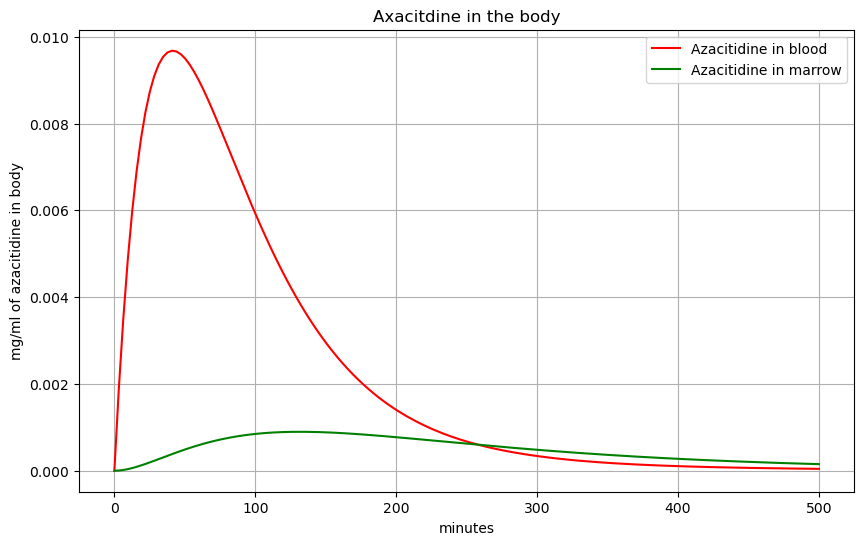

AUC of central compartment (blood) 1.1831759930619872
AUC of peripheralcompartment (bone marrow tissue) 0.2515093220853283


"\nC= 0.075\n\ntp = np.linspace(1,500, 160) \nplt.figure(figsize=(10,6))\nxVal = tp\n#ret = odeint(plasma_Conct,y0,t)\n#C = ret.T\nplt.plot(xVal, plasma_Conct(tp), 'b', label='plasma conct')\nplt.legend()\nplt.grid(True)\nplt.show()\n"

In [2]:
import numpy as np
from scipy.integrate import trapezoid 
from scipy.integrate import odeint
import matplotlib.pyplot as plt
def Aza_Effect(y,t,c1 = 0.1, c2 =0.1,p1 = 0.1,a1 = 0.875, d2 = 2.3):
    gut,C1,C2 = y

    F = 0.125 #percent absorbed by the body, bioavailability ~12.5% for oral dose of 300mg
    ka = 0.0173 #the first order absorption rate constant, 0.0173/min which was converted from 1.04/hr
    D0 = 0.300 #dose of the drug, 300mg
    k10 = 0.03151 #1.8902 #hr  #0.03151 in minutes   #1/hr (elimination rate)
    k12 = 0.00149  #0.0892  #assumption that the k12 is leaving so clearance into the peripheral to get the numbers - 
    k21 = 0.00641   #0.3847 (Q/volume of the intercompartment model)
    #rate at which azacitidine leaves the gut to go into blood - rate it leaves blood to go into marrow +rate it goes back into blood from marrow
    dC1dt = F*ka*D0*np.exp(-ka*t) - (k10 + k12)*C1 + k21*C2 
    dC2dt = k12*C1 - k21*C2
    dXDeaddt = gut*Xl1
    return [dgutdt,dC1dt,dC2dt]


Gut =0
out = 0
N=1000
Xl1 =1000
Xl2 = 0
Dead = 0
C1 = 0
C2=0
t = np.linspace(0,500, 160)    
y0 = Gut,C1,C2
ret = odeint(Aza_Effect,y0,t)
Gut,C1,C2 = ret.T
plt.figure(figsize=(10, 6))
plt.plot(t, C1, 'r', label='Azacitidine in blood')
plt.plot(t, C2, 'g', label='Azacitidine in marrow')

tb = np.linspace(0,500, 160)  

plt.title('Axacitdine in the body')
plt.xlabel('minutes')
plt.ylabel('mg/ml of azacitidine in body')
plt.legend()
plt.grid(True)
plt.show()

auc_central = trapezoid(C1, t)     #np.trapezoid(C1, t) 
auc_peripheral = trapezoid(C2, t)         #np.trapezoid(C2, t) 
print ("AUC of central compartment (blood)", auc_central)
print ("AUC of peripheralcompartment (bone marrow tissue)", auc_peripheral)
